# Pythonセミナー第5回課題：糖尿病データのクラス分類

`diabetes.csv`を用いて、k近傍法（kNN）とRandom Forestのクラス分類モデルを構築します。各手法について、デフォルト設定とハイパーパラメータチューニング後の性能を比較します。

In [ ]:
#* データ処理・グラフ作成・機械学習に必要なライブラリを読み込む
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             precision_score, recall_score, f1_score)

#* グラフの基本的な表示設定を指定する
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

#* 同じ乱数を使い、実行するたびに同じ結果を再現できるようにする(seed値を設定する)
RANDOM_STATE = 42

#* モデル構築とデータ分割に使用する設定値
k_in_knn = 5  # k-NNにおけるkの値
fold_number = 5  # N-fold CVのN
number_of_test_samples = 154  # テストデータのサンプル数

Matplotlib is building the font cache; this may take a moment.


## 1. データの読み込みと確認

In [2]:
#* 糖尿病データをPandasのDataFrameとして読み込む
df = pd.read_csv('diabetes.csv')

#* データの先頭5行を表示して、列名と値を確認する
display(df.head())

#* データ数・列数、欠損値の数、目的変数のクラス数を確認する
print(f'データ数: {df.shape[0]}、列数: {df.shape[1]}')
print(f'欠損値の合計: {df.isnull().sum().sum()}')
print('\nOutcomeのクラス数:')
display(df['Outcome'].value_counts().sort_index().rename('件数').to_frame())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


データ数: 768、列数: 9
欠損値の合計: 0

Outcomeのクラス数:


,件数
Outcome,
0,500
1,268


In [3]:
#* Outcomeを目的変数y、Outcome以外の8列を説明変数Xに分ける
target = 'Outcome'
X = df.drop(columns=[target])
y = df[target]

#* クラス比率を保ちながら、データをトレーニングデータとテストデータに分割する
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=number_of_test_samples,
    shuffle=True,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'目的変数: {target}')
print(f'説明変数の数: {X.shape[1]}')
print(f'トレーニングデータ: {X_train.shape[0]}件')
print(f'テストデータ: {X_test.shape[0]}件')
print(f'トレーニングデータの陽性率: {y_train.mean():.3f}')
print(f'テストデータの陽性率: {y_test.mean():.3f}')

目的変数: Outcome
説明変数の数: 8
トレーニングデータ: 614件
テストデータ: 154件
トレーニングデータの陽性率: 0.349
テストデータの陽性率: 0.351


## 2. 評価用の関数

`Outcome = 1`を陽性クラスとして、Accuracy・Precision・Recall・F1を計算します。ROC曲線とPR曲線を描くため、陽性クラスの予測確率も保存します。

In [4]:
#* 学習済みモデルの予測結果と4つの評価指標をまとめる関数を定義する
def evaluate_model(model, X_test, y_test, model_name):
    #* テストデータのクラスと、陽性クラスになる確率を予測する
    predicted_class = model.predict(X_test)
    predicted_probability = model.predict_proba(X_test)[:, 1]

    #* Accuracy・Precision・Recall・F1を計算する
    scores = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predicted_class),
        'Precision': precision_score(y_test, predicted_class, zero_division=0),
        'Recall': recall_score(y_test, predicted_class, zero_division=0),
        'F1': f1_score(y_test, predicted_class, zero_division=0)
    }

    print(f'【{model_name}】')
    print(f"Accuracy : {scores['Accuracy']:.4f}")
    print(f"Precision: {scores['Precision']:.4f}")
    print(f"Recall   : {scores['Recall']:.4f}")
    print(f"F1       : {scores['F1']:.4f}")
    return scores, predicted_class, predicted_probability

## 3. kNN：デフォルトモデル

kNNは特徴量間の距離を利用するため、トレーニングデータの平均と標準偏差を使って説明変数をオートスケーリングします。テストデータにもトレーニングデータと同じ平均・標準偏差を使用します。

In [5]:
#* オートスケーリング
autoscaled_x_train = (X_train - X_train.mean()) / X_train.std()
autoscaled_x_test = (X_test - X_train.mean()) / X_train.std()

#* k-NN
model = KNeighborsClassifier(n_neighbors=k_in_knn, metric='euclidean')  # モデルの宣言
model.fit(autoscaled_x_train, y_train)  # モデルの構築

#* テストデータでデフォルトkNNモデルの性能を評価する
knn_default_scores, knn_default_pred, knn_default_prob = evaluate_model(
    model, autoscaled_x_test, y_test, 'kNN Default'
)

【kNN Default】
Accuracy : 0.7013
Precision: 0.5833
Recall   : 0.5185
F1       : 0.5490


## 4. kNN：ハイパーパラメータチューニング

5分割の層化交差検証を用い、近傍数、距離による重み付け、距離の種類を探索します。最良モデルは交差検証のAccuracyで選択します。

In [6]:
#* 各分割でクラス比率を保つ5分割交差検証を設定する
cv = StratifiedKFold(n_splits=fold_number, shuffle=True, random_state=RANDOM_STATE)

#* kNNで探索するハイパーパラメータの候補を設定する
knn_param_grid = {
    'knn__n_neighbors': list(range(3, 22, 2)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

#* 交差検証Accuracyが最大になるkNNの組み合わせを総当たりで探索する
knn_grid_search = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    param_grid=knn_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True
)
knn_grid_search.fit(X_train, y_train)

#* 最良のハイパーパラメータと交差検証Accuracyを表示する
print('kNNの最良ハイパーパラメータ:')
print(knn_grid_search.best_params_)
print(f'交差検証の最良Accuracy: {knn_grid_search.best_score_:.4f}')

#* 最良パラメータで再学習されたkNNモデルを取り出して評価する
knn_tuned = knn_grid_search.best_estimator_
knn_tuned_scores, knn_tuned_pred, knn_tuned_prob = evaluate_model(
    knn_tuned, X_test, y_test, 'kNN Tuned'
)

kNNの最良ハイパーパラメータ:
{'knn__n_neighbors': 17, 'knn__p': 1, 'knn__weights': 'distance'}
交差検証の最良Accuracy: 0.7639
【kNN Tuned】
Accuracy : 0.7727
Precision: 0.7317
Recall   : 0.5556
F1       : 0.6316


## 5. Random Forest：デフォルトモデル

Random Forestは決定木を多数組み合わせる分類手法です。決定木は特徴量の大小関係で分岐するため、kNNと異なり標準化は行いません。`random_state`だけは結果を再現するために固定します。

In [7]:
#* 再現性を固定したデフォルト設定のRandom Forestモデルを作成する
rf_default = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

#* トレーニングデータを使ってデフォルトRandom Forestモデルを学習する
rf_default.fit(X_train, y_train)

#* テストデータでデフォルトRandom Forestモデルの性能を評価する
rf_default_scores, rf_default_pred, rf_default_prob = evaluate_model(
    rf_default, X_test, y_test, 'Random Forest Default'
)

【Random Forest Default】
Accuracy : 0.7727
Precision: 0.7111
Recall   : 0.5926
F1       : 0.6465


## 6. Random Forest：ハイパーパラメータチューニング

決定木の数、各分岐で調べる特徴量数、木の深さ、分岐に必要な最小サンプル数を探索します。kNNと同じ5分割交差検証とAccuracyを使用します。

In [8]:
#* Random Forestで探索するハイパーパラメータの候補を設定する
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

#* 交差検証Accuracyが最大になるRandom Forestの組み合わせを総当たりで探索する
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True
)
rf_grid_search.fit(X_train, y_train)

#* 最良のハイパーパラメータと交差検証Accuracyを表示する
print('Random Forestの最良ハイパーパラメータ:')
print(rf_grid_search.best_params_)
print(f'交差検証の最良Accuracy: {rf_grid_search.best_score_:.4f}')

#* 最良パラメータで再学習されたRandom Forestモデルを取り出して評価する
rf_tuned = rf_grid_search.best_estimator_
rf_tuned_scores, rf_tuned_pred, rf_tuned_prob = evaluate_model(
    rf_tuned, X_test, y_test, 'Random Forest Tuned'
)

Random Forestの最良ハイパーパラメータ:
{'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}
交差検証の最良Accuracy: 0.7801
【Random Forest Tuned】
Accuracy : 0.7532
Precision: 0.6739
Recall   : 0.5741
F1       : 0.6200


## 7. Accuracy・Precision・Recall・F1の比較

In [9]:
#* 4モデルの評価指標を1つの表にまとめて比較する
comparison_df = pd.DataFrame([
    knn_default_scores,
    knn_tuned_scores,
    rf_default_scores,
    rf_tuned_scores
]).set_index('Model')

display(comparison_df.round(4))

,Accuracy,Precision,Recall,F1
Model,,,,
kNN Default,0.7013,0.5833,0.5185,0.5490
kNN Tuned,0.7727,0.7317,0.5556,0.6316
Random Forest Default,0.7727,0.7111,0.5926,0.6465
Random Forest Tuned,0.7532,0.6739,0.5741,0.6200


## 8. 混同行列

行が実際のクラス、列が予測したクラスです。左上は真陰性、右上は偽陽性、左下は偽陰性、右下は真陽性を表します。

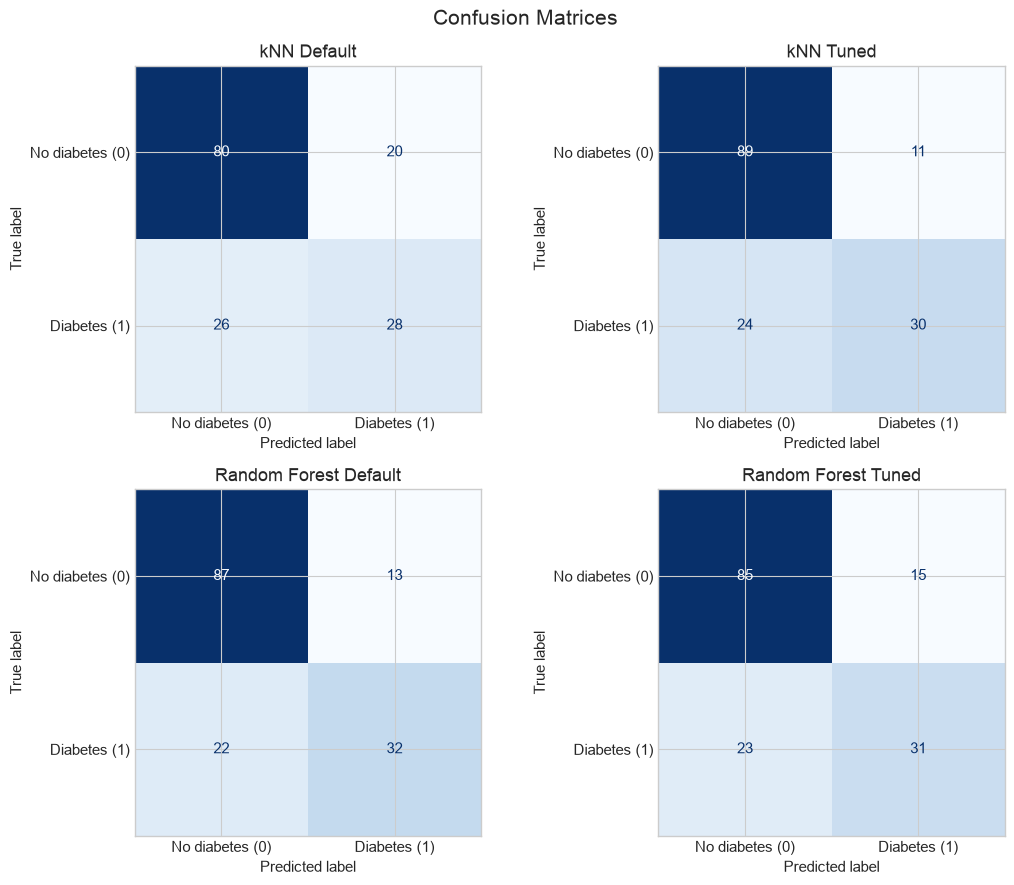

In [10]:
#* 4モデルの予測クラスをモデル名と対応させる
predictions = {
    'kNN Default': knn_default_pred,
    'kNN Tuned': knn_tuned_pred,
    'Random Forest Default': rf_default_pred,
    'Random Forest Tuned': rf_tuned_pred
}

#* kNNとRandom Forestのデフォルト・チューニング後の混同行列を表示する
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (model_name, predicted_class) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicted_class,
        display_labels=['No diabetes (0)', 'Diabetes (1)'],
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(model_name)
plt.suptitle('Confusion Matrices', fontsize=15)
plt.tight_layout()
plt.show()

## 9. ROC曲線

ROC曲線は偽陽性率と真陽性率（Recall）の関係を示します。曲線が左上に近く、AUCが1に近いほど分類性能が高いことを表します。

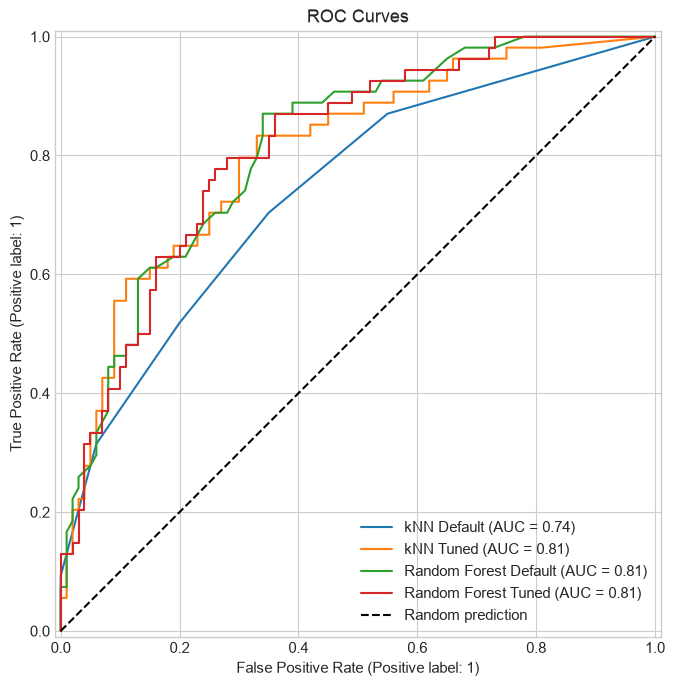

In [11]:
#* 4モデルの陽性クラスの予測確率をモデル名と対応させる
probabilities = {
    'kNN Default': knn_default_prob,
    'kNN Tuned': knn_tuned_prob,
    'Random Forest Default': rf_default_prob,
    'Random Forest Tuned': rf_tuned_prob
}

#* 4モデルのROC曲線を同じグラフに描いて比較する
fig, ax = plt.subplots(figsize=(8, 7))
for model_name, predicted_probability in probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        predicted_probability,
        name=model_name,
        ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random prediction')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Precision-Recall曲線

PR曲線は判定しきい値を変化させたときのPrecisionとRecallの関係を示します。陽性クラスが少ない不均衡データでは、陽性クラスの分類性能を確認するために有用です。

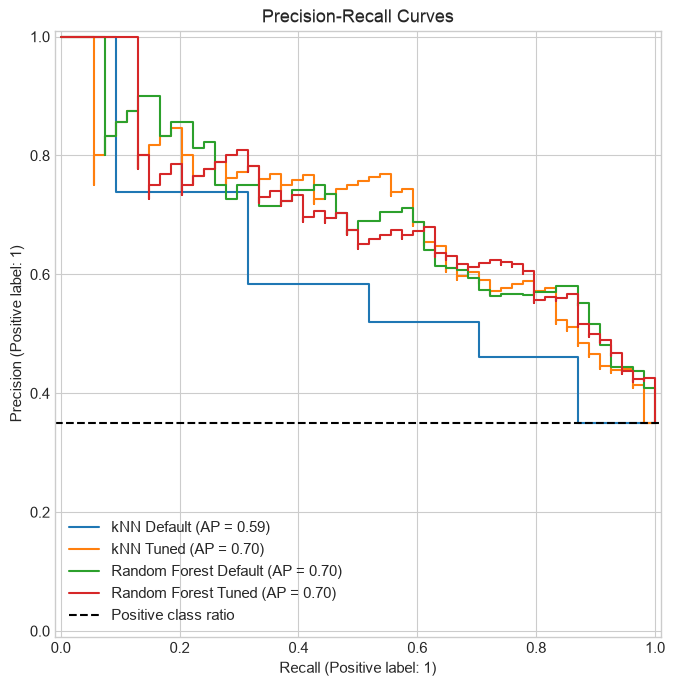

In [12]:
#* 4モデルのPR曲線を同じグラフに描いて比較する
fig, ax = plt.subplots(figsize=(8, 7))
for model_name, predicted_probability in probabilities.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        predicted_probability,
        name=model_name,
        ax=ax
    )
ax.axhline(y=y_test.mean(), color='black', linestyle='--', label='Positive class ratio')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 11. 結果の確認

チューニングではトレーニングデータ内の交差検証Accuracyが最も高いモデルを選びました。ただし、未知データに対する各評価指標が必ずすべて向上するとは限りません。最終的な比較ではAccuracyだけでなく、陽性者の見逃しに関係するRecall、陽性予測の信頼性に関係するPrecision、それらのバランスを示すF1、ROC曲線、PR曲線、混同行列を合わせて確認します。